In [ ]:
import numpy as np
import tensorflow as tf


In [ ]:
data = np.load("fer2013_full.npz", mmap_mode="r")

x_test  = data["x_test"]
y_test  = data["y_test"]

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("cnn_fer2013_57.keras")
model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)                   │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_24 (Activation)           │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 24, 24, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_25 (Activation)           │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_26 (Activation)           │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_27 (Activation)           │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 9,001,751 (34.34 MB)

 Trainable params: 2,999,431 (11.44 MB)

 Non-trainable params: 3,456 (13.50 KB)

 Optimizer params: 5,998,864 (22.88 MB)

In [ ]:

y_true = y_test


In [ ]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)


225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step


In [ ]:
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx = np.where(y_pred != y_true)[0]

print("Correct:", len(correct_idx))
print("Wrong:", len(wrong_idx))


Correct: 4107
Wrong: 3071


In [ ]:
emotion_labels = [
    "Angry", "Disgust", "Fear",
    "Happy", "Neutral", "Sad", "Surprise",
]


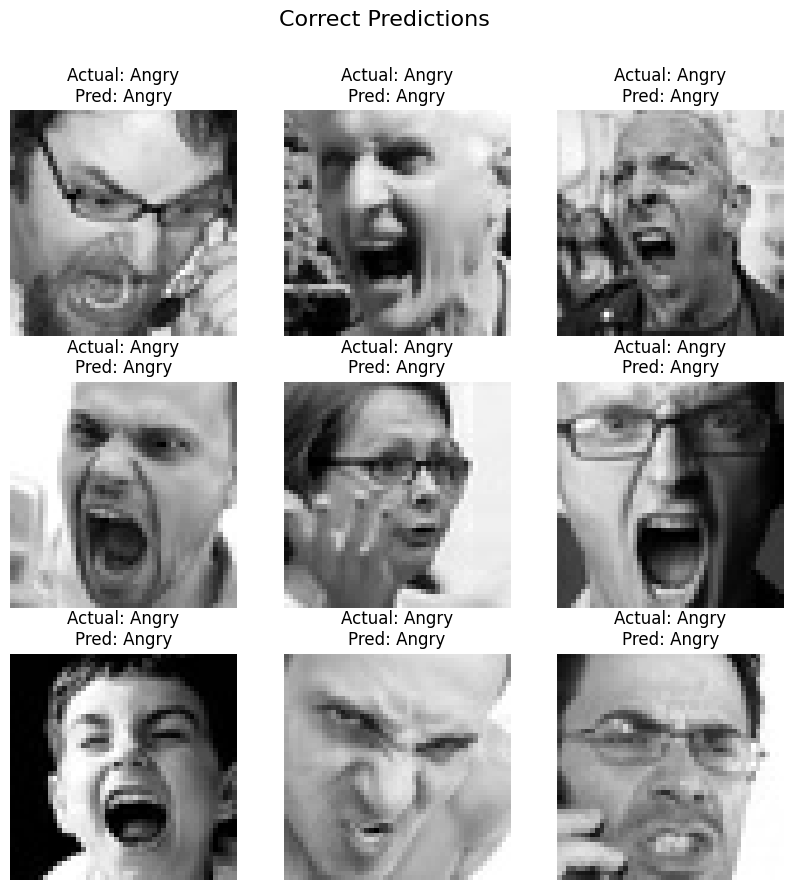

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i, idx in enumerate(correct_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].reshape(48, 48), cmap="gray")
    plt.title(
        f"Actual: {emotion_labels[y_true[idx]]}\n"
        f"Pred: {emotion_labels[y_pred[idx]]}"
    )
    plt.axis("off")

plt.suptitle("Correct Predictions", fontsize=16)
plt.show()


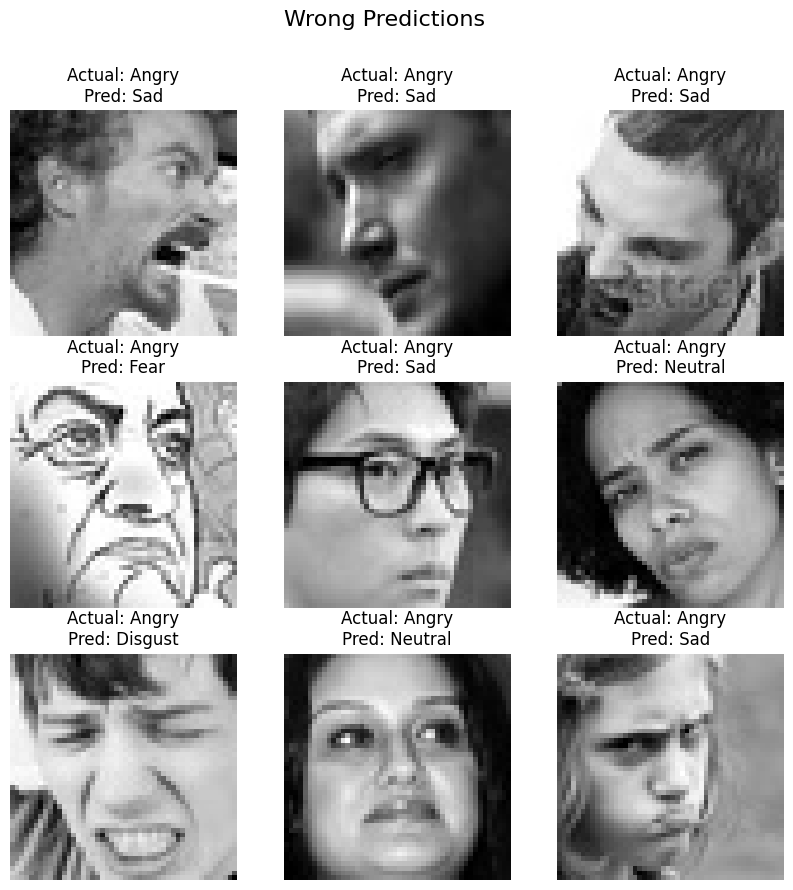

In [ ]:
plt.figure(figsize=(10, 10))

for i, idx in enumerate(wrong_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].reshape(48, 48), cmap="gray")
    plt.title(
        f"Actual: {emotion_labels[y_true[idx]]}\n"
        f"Pred: {emotion_labels[y_pred[idx]]}"
    )
    plt.axis("off")

plt.suptitle("Wrong Predictions", fontsize=16)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=emotion_labels,
    digits=4
))

              precision    recall  f1-score   support

       Angry     0.6169    0.3278    0.4281       958
     Disgust     0.4835    0.3964    0.4356       111
        Fear     0.5066    0.1504    0.2319      1024
       Happy     0.7832    0.8185    0.8004      1774
     Neutral     0.4907    0.6018    0.5406      1233
         Sad     0.3888    0.6255    0.4796      1247
    Surprise     0.6885    0.7473    0.7167       831

    accuracy                         0.5722      7178
   macro avg     0.5655    0.5239    0.5190      7178
weighted avg     0.5872    0.5722    0.5539      7178



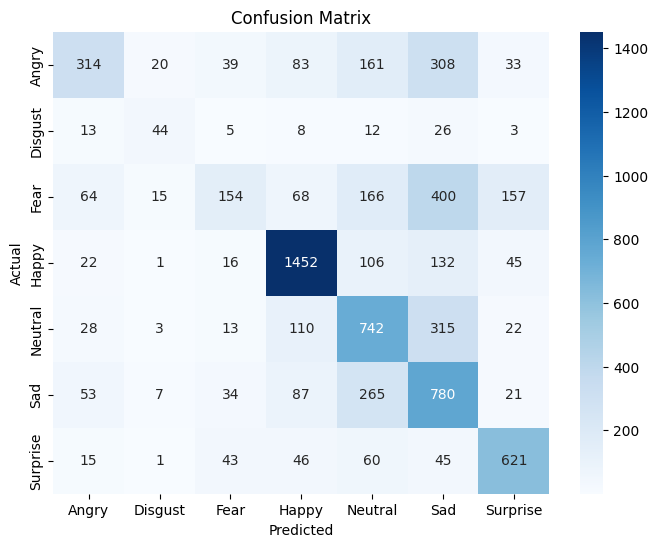

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


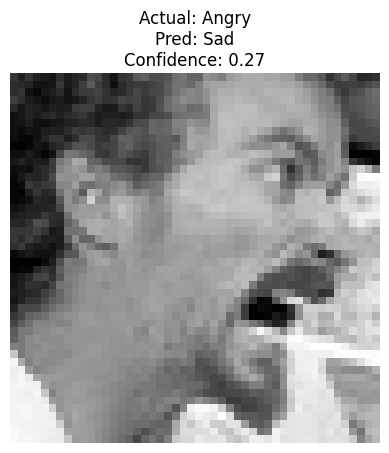

In [ ]:
idx = wrong_idx[0]

plt.imshow(x_test[idx].reshape(48,48), cmap="gray")
plt.title(
    f"Actual: {emotion_labels[y_true[idx]]}\n"
    f"Pred: {emotion_labels[y_pred[idx]]}\n"
    f"Confidence: {np.max(y_pred_probs[idx]):.2f}"
)
plt.axis("off")
plt.show()
